The objective of this project is to build random forest model based on automobile data given to you

You have been given cars data with diff combination of safty features , capacity etc . your model should able to predict wheather the car is acceptable , unaccptable , good or very good

The column in the dataset are 'buying','maint','doors','persons','lug_boot','safety' and the final output as 'class'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, f1_score, precision_score, recall_score

In [37]:
df=pd.read_csv('/content/sample_data/car_evaluation.csv', names=['buying','maint','doors','persons','lug_boot','safety','class'], header=None)

In [5]:
df.shape

(1728, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [7]:
df.describe().T

,count,unique,top,freq
buying,1728,4,vhigh,432
maint,1728,4,vhigh,432
doors,1728,4,2,432
persons,1728,3,2,576
lug_boot,1728,3,small,576
safety,1728,3,low,576
class,1728,4,unacc,1210


In [8]:
df.tail()

,buying,maint,doors,persons,lug_boot,safety,class
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood


In [9]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.columns:
  print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [38]:
## Encoding

### Save the encodings

encoders = {}

buying_encoding = LabelEncoder()
df['buying'] = buying_encoding.fit_transform(df['buying'])
encoders['buying'] = buying_encoding

maint_encoding = LabelEncoder()
df['maint'] = maint_encoding.fit_transform(df['maint'])
encoders['maint'] = maint_encoding

doors_encoding = LabelEncoder()
df['doors'] = doors_encoding.fit_transform(df['doors'])
encoders['doors'] = doors_encoding

persons_encoding = LabelEncoder()
df['persons'] = persons_encoding.fit_transform(df['persons'])
encoders['persons'] = persons_encoding

lug_boot_encoding = LabelEncoder()
df['lug_boot'] = lug_boot_encoding.fit_transform(df['lug_boot'])
encoders['lug_boot'] = lug_boot_encoding

safety_encoding = LabelEncoder()
df['safety'] = safety_encoding.fit_transform(df['safety'])
encoders['safety'] = safety_encoding

class_encoding = LabelEncoder()
df['class'] = class_encoding.fit_transform(df['class'])
encoders['class'] = class_encoding

In [13]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2
...,...,...,...,...,...,...,...
1723,1,1,3,2,1,2,1
1724,1,1,3,2,1,0,3
1725,1,1,3,2,0,1,2
1726,1,1,3,2,0,2,1


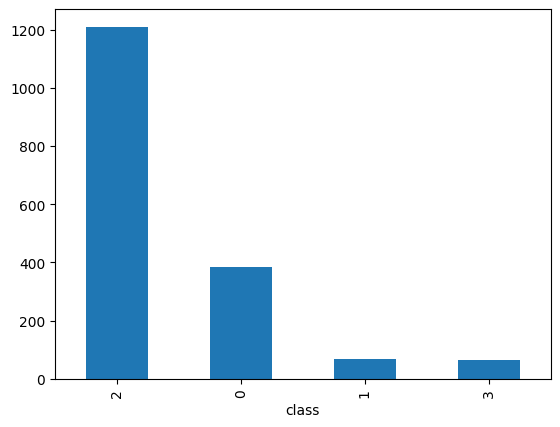

In [14]:
## count plt for class

df['class'].value_counts().plot(kind='bar')
plt.show()

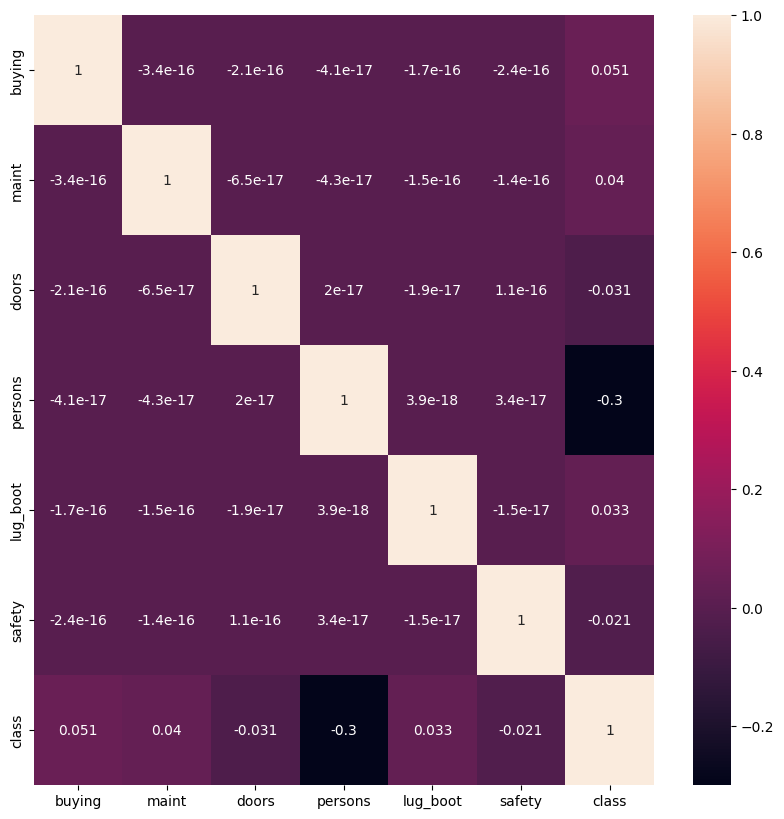

In [15]:
## correlation matrix

import seaborn as sns

plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [16]:
## ML model building

X = df.drop('class', axis=1)
y = df['class']

In [18]:
X

,buying,maint,doors,persons,lug_boot,safety
0,3,3,0,0,2,1
1,3,3,0,0,2,2
2,3,3,0,0,2,0
3,3,3,0,0,1,1
4,3,3,0,0,1,2
...,...,...,...,...,...,...
1723,1,1,3,2,1,2
1724,1,1,3,2,1,0
1725,1,1,3,2,0,1
1726,1,1,3,2,0,2


In [19]:
y

,class
0,2
1,2
2,2
3,2
4,2
...,...
1723,1
1724,3
1725,2
1726,1


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
rf = RandomForestClassifier(n_estimators=100)

In [22]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [23]:
## Prediction on X test

y_pred = rf.predict(X_test)

In [24]:
## Evalaution of model

acc = accuracy_score(y_test, y_pred)
conf_mat = confusion_matrix(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

In [25]:
## print

print("Accuracy: ", acc)
print("Precision: ", prec)
print("Recall: ", rec)
print("F1 score: ", f1)

Accuracy:  0.9826589595375722
Precision:  0.9840102094437354
Recall:  0.9826589595375722
F1 score:  0.9827055267806715


Text(0.5, 1.0, 'Random Forest Feature Importance')

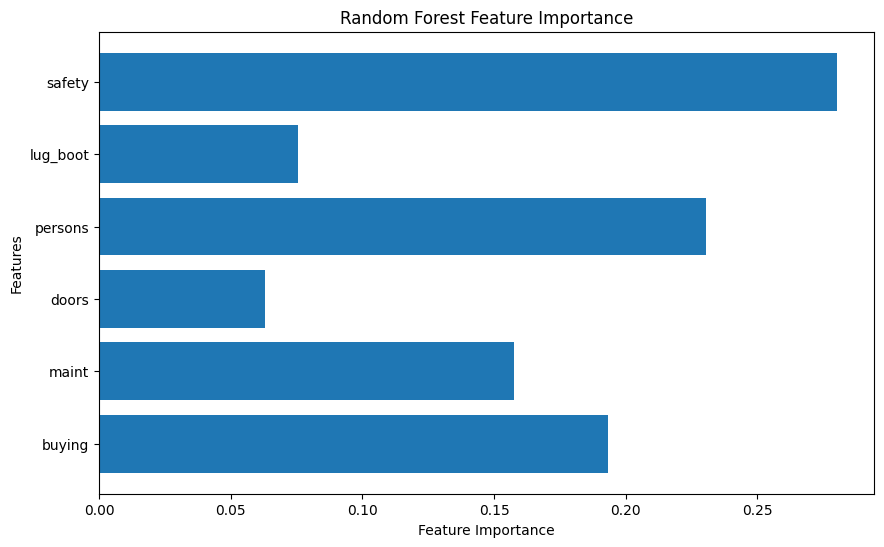

In [26]:
## Feature importance
feature_importances = rf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')

In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
param_grids = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [29]:
grid = GridSearchCV(estimator=rf, param_grid=param_grids, cv=5, scoring='accuracy')

In [30]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [31]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9594830743473028


In [32]:
best_rf = grid.best_estimator_

In [33]:
## Prediction

y_pred = best_rf.predict(X_test)

In [34]:
## Model evaluation based on hyper parameters

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc}")

prec = precision_score(y_test, y_pred, average='weighted')
print(f"Precision: {prec}")

rec = recall_score(y_test, y_pred, average='weighted')
print(f"Recall: {rec}")



print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9739884393063584
Precision: 0.9759113212109866
Recall: 0.9739884393063584
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        71
           1       0.95      0.90      0.92        20
           2       1.00      0.98      0.99       242
           3       1.00      0.85      0.92        13

    accuracy                           0.97       346
   macro avg       0.96      0.93      0.94       346
weighted avg       0.98      0.97      0.97       346

[[ 70   1   0   0]
 [  2  18   0   0]
 [  4   0 238   0]
 [  2   0   0  11]]


In [ ]:
## Predict for new patient

new_patient = pd.DataFrame({
    'buying': 'low',
    'maint': 'low',
    'doors': '4',
    'persons': '4',
    'lug_boot': 'big',
    'safety': 'high'
})

In [43]:
# Iterate over the feature columns (X.columns) and encode new_patient
for col in X.columns:
  new_patient[col] = encoders[col].transform(new_patient[col])

NameError: name 'new_patient' is not defined

In [44]:

# Iterate over the feature columns (X.columns) instead of all df columns
for col in X.columns:
  new_df[col] = encoders[col].transform(new_df[col])

In [45]:
new_df

,buying,maint,doors,persons,lug_boot,safety
0,1,1,2,1,0,0


In [46]:
prediction = best_rf.predict(new_df)

In [47]:
prediction

array([3])

In [48]:
## reverse encoding

result = encoders['class'].inverse_transform(prediction)
print(result)

['vgood']
